# Pupil features 

In [1]:
# --- JUPYTER: concatenate cleaned participants into one DF (with QC filtering) ---

from pathlib import Path
import pandas as pd

# =========================
# Paths (edit if needed)
# =========================
CLEAN_DIR = Path("../data/by_participant_cleaned_right")      # cleaned per-participant CSVs
QC_LOG_PATH = Path("../data/qc_cleaning_log_right.csv")       # trial-level QC log you wrote
OUT_PATH = Path("../data/cleaned_all_participants_right.csv") # combined output

# =========================
# Load QC log and decide who is kept
# =========================
qc = pd.read_csv(QC_LOG_PATH)

# "kept trial" = exclude_trial == False
qc["kept_trial"] = ~qc["exclude_trial"].astype(bool)

# Participant exclusion rule: kept trials < 50% of total trials
part_sum = (
    qc.groupby("participant", as_index=False)
      .agg(total_trials=("trial", "nunique"),
           kept_trials=("kept_trial", "sum"))
)
part_sum["kept_fraction"] = part_sum["kept_trials"] / part_sum["total_trials"]
part_sum["exclude_participant"] = part_sum["kept_fraction"] < 0.50

kept_participants = set(part_sum.loc[~part_sum["exclude_participant"], "participant"])
excluded_participants = set(part_sum.loc[part_sum["exclude_participant"], "participant"])

print("=== Participant exclusion summary (first 15) ===")
display(part_sum.sort_values("kept_fraction").head(15))

print(f"\nKept participants: {len(kept_participants)}")
print(f"Excluded participants: {len(excluded_participants)}")

# Build the set of (participant, trial) pairs we want to keep
kept_pairs = set(
    qc.loc[qc["kept_trial"], ["participant", "trial"]]
      .itertuples(index=False, name=None)
)

# =========================
# Load cleaned files, filter, concatenate
# =========================
dfs = []
missing_files = []

for csv_path in sorted(CLEAN_DIR.glob("participant_*.csv")):
    df = pd.read_csv(csv_path, low_memory=False)

    if "participant" not in df.columns:
        raise ValueError(f"{csv_path.name} has no 'participant' column.")

    pid = df["participant"].iloc[0]

    # skip excluded participants
    if pid not in kept_participants:
        continue

    # keep only kept trials for this participant
    # (trial IDs are strings like "Trial001" so keep as string)
    df["trial"] = df["trial"].astype(str)

    df = df[df.apply(lambda r: (r["participant"], r["trial"]) in kept_pairs, axis=1)]
    dfs.append(df)

if not dfs:
    raise RuntimeError("No data loaded after filtering. Check paths + QC log.")

cleaned_all_df = pd.concat(dfs, ignore_index=True)

print(f"\nLoaded & concatenated rows: {len(cleaned_all_df):,}")
print(f"Participants in combined DF: {cleaned_all_df['participant'].nunique()}")
print(f"Trials in combined DF: {cleaned_all_df[['participant','trial']].drop_duplicates().shape[0]}")

# =========================
# Sanity checks
# =========================
required_cols = {"participant", "trial", "time_ms", "t_rel_ms", "pupil_right_bc"}
missing = required_cols - set(cleaned_all_df.columns)
if missing:
    print(f"\nWARNING: missing required columns: {missing}")
else:
    print("\nAll required columns present.")

print("\nBaseline-corrected pupil summary (pupil_right_bc):")
display(cleaned_all_df["pupil_right_bc"].describe())

# =========================
# Save combined dataset
# =========================
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
cleaned_all_df.to_csv(OUT_PATH, index=False)
print(f"\nSaved combined dataset -> {OUT_PATH}")

# Also save participant summary table (useful for Methods appendix)
PART_SUM_OUT = OUT_PATH.with_name("qc_participant_keep_summary.csv")
part_sum.to_csv(PART_SUM_OUT, index=False)
print(f"Saved participant keep summary -> {PART_SUM_OUT}")

=== Participant exclusion summary (first 15) ===


,participant,total_trials,kept_trials,kept_fraction,exclude_participant
19,22,33,1,0.030303,True
26,29,33,2,0.060606,True
21,24,33,2,0.060606,True
7,8,19,4,0.210526,True
53,56,33,8,0.242424,True
51,54,33,8,0.242424,True
28,31,33,12,0.363636,True
54,57,33,12,0.363636,True
27,30,33,12,0.363636,True
24,27,34,13,0.382353,True



Kept participants: 44
Excluded participants: 13

Loaded & concatenated rows: 8,034,369
Participants in combined DF: 44
Trials in combined DF: 858

All required columns present.

Baseline-corrected pupil summary (pupil_right_bc):


count    7.643064e+06
mean    -1.840230e-01
std      8.017752e-01
min     -3.837567e+00
25%     -4.576048e-01
50%     -5.352571e-02
75%      2.230293e-01
max      5.496444e+00
Name: pupil_right_bc, dtype: float64


Saved combined dataset -> ../data/cleaned_all_participants_right.csv
Saved participant keep summary -> ../data/qc_participant_keep_summary.csv


In [ ]:
import pandas as pd

csv_path = "../data/cleaned_all_participants_right.csv"
parquet_path = "../data/cleaned_all_participants_right.parquet"

# Only keep what you actually need (edit this list!)
usecols = [
    "participant",
    "trial",
    "stim_category",
    "t_rel_ms",
    "time_ms",

    # pupil
    "pupil_right_bc",
    "pupil_right_clean",

    # gaze events
    "category_right",

    # gaze positions
    "por_right_x_px",
    "por_right_y_px",

]
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)

# Make it smaller + faster
df["participant"] = df["participant"].astype("int16")
df["trial"] = df["trial"].astype("category")
df["stim_category"] = df["stim_category"].astype("category")
df["t_rel_ms"] = pd.to_numeric(df["t_rel_ms"], errors="coerce").astype("float32")
df["time_ms"] = pd.to_numeric(df["time_ms"], errors="coerce").astype("float64")

df["pupil_right_bc"] = pd.to_numeric(df["pupil_right_bc"], errors="coerce").astype("float32")
df["pupil_right_clean"] = pd.to_numeric(df["pupil_right_clean"], errors="coerce").astype("float32")

df["category_right"] = df["category_right"].astype("category")

df["por_right_x_px"] = pd.to_numeric(df["por_right_x_px"], errors="coerce").astype("float32")
df["por_right_y_px"] = pd.to_numeric(df["por_right_y_px"], errors="coerce").astype("float32")


df.to_parquet(parquet_path, index=False)
print("Wrote:", parquet_path, "rows:", len(df))

Wrote: ../data/cleaned_all_participants_right.parquet rows: 8034369


In [11]:
import pandas as pd

all_df_kept = pd.read_parquet(
    "../data/cleaned_all_participants_right.parquet"
)

print("Rows:", len(all_df_kept))
print("Participants:", all_df_kept["participant"].nunique())
print("Trials:", all_df_kept["trial"].nunique())

Rows: 8034369
Participants: 44
Trials: 34


In [12]:
base = all_df_kept.loc[all_df_kept["t_rel_ms"].between(0, 500)]

base_means = (
    base.groupby(["participant", "trial"])["pupil_right_bc"]
    .mean()
    .dropna()
)

print("Median baseline mean:", base_means.median())
print("IQR:", base_means.quantile([0.25, 0.75]))

Median baseline mean: 0.0
IQR: 0.25   -2.452866e-10
0.75    3.137087e-10
Name: pupil_right_bc, dtype: float64


/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/2564714145.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  base.groupby(["participant", "trial"])["pupil_right_bc"]


In [13]:
base_std = (
    base.groupby(["participant", "trial"], observed=True)["pupil_right_bc"]
    .std()
    .dropna()
)

print(base_std.describe())
print("Median baseline SD:", float(base_std.median()))
print("Share baseline SD > 0.2:", float((base_std > 0.2).mean()))

count    709.000000
mean       0.104346
std        0.095484
min        0.000000
25%        0.052263
50%        0.079600
75%        0.131273
max        1.017719
Name: pupil_right_bc, dtype: float64
Median baseline SD: 0.07959989458322525
Share baseline SD > 0.2: 0.11142454160789844


### Trial-level pupil features (RIGHT eye, baseline-corrected)

For each trial:
	•	Peak dilation
Maximum pupil dilation relative to baseline
→ reflects strongest response amplitude
	•	Mean response
Mean pupil size across the trial
→ captures sustained dilation
	•	SD over trial
Standard deviation of pupil size
→ reflects variability / instability
	•	Velocity (mean & peak)
First temporal derivative of pupil size (mm/s)
→ captures how fast the pupil changes

All features are computed after baseline correction.

In [14]:
import pandas as pd
import numpy as np

df = df.sort_values(["participant", "trial", "t_rel_ms"])

# Time difference in seconds
dt = (
    df.groupby(["participant", "trial"])["t_rel_ms"]
    .diff()
    .div(1000.0)
)

# Pupil difference
dp = df.groupby(["participant", "trial"])["pupil_right_bc"].diff()

# Velocity (mm/s)
df["pupil_velocity"] = dp / dt

trial_features = (
    df.groupby(["participant", "trial", "stim_category"])
    .agg(
        # amplitude
        peak_dilation=("pupil_right_bc", "max"),
        mean_response=("pupil_right_bc", "mean"),
        sd_response=("pupil_right_bc", "std"),

        # dynamics
        mean_velocity=("pupil_velocity", "mean"),
        peak_velocity=("pupil_velocity", lambda x: np.nanmax(np.abs(x))),
    )
    .reset_index()
)

trial_features.describe()

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/2982562219.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["participant", "trial"])["t_rel_ms"]
/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/2982562219.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dp = df.groupby(["participant", "trial"])["pupil_right_bc"].diff()
/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/2982562219.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

,participant,peak_dilation,mean_response,sd_response,mean_velocity,peak_velocity
count,52360.000000,1866.000000,1866.000000,1866.000000,1430.0,1751.000000
mean,28.431818,0.448430,-0.135709,0.219372,NaN,inf
std,16.682210,0.773827,0.596487,0.156468,NaN,NaN
min,1.000000,-2.262101,-3.207335,0.000000,-inf,0.000000
25%,13.750000,0.105371,-0.291483,0.116023,NaN,54.876475
50%,30.000000,0.352850,-0.024480,0.184800,0.0,NaN
75%,43.250000,0.758698,0.125462,0.290181,NaN,NaN
max,55.000000,5.496444,2.248111,1.171064,inf,inf


In [15]:
participant_features = (
    trial_features
    .groupby(["participant", "stim_category"])
    .agg(
        # amplitude
        peak_dilation_median=("peak_dilation", "median"),
        peak_dilation_mean=("peak_dilation", "mean"),

        mean_response_median=("mean_response", "median"),
        mean_response_mean=("mean_response", "mean"),

        # variability
        sd_response_median=("sd_response", "median"),

        # dynamics
        mean_velocity_median=("mean_velocity", "median"),
        peak_velocity_median=("peak_velocity", "median"),

        # QC
        n_trials=("trial", "nunique"),
    )
    .reset_index()
)

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/4007068718.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["participant", "stim_category"])


Participant-condition rows for plotting: 1540
Participants included: 44


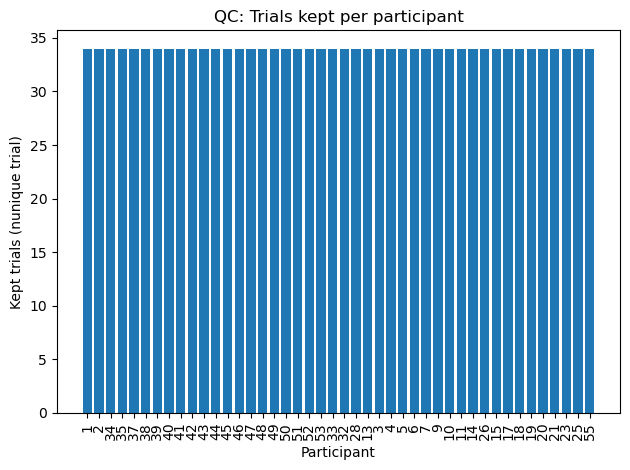

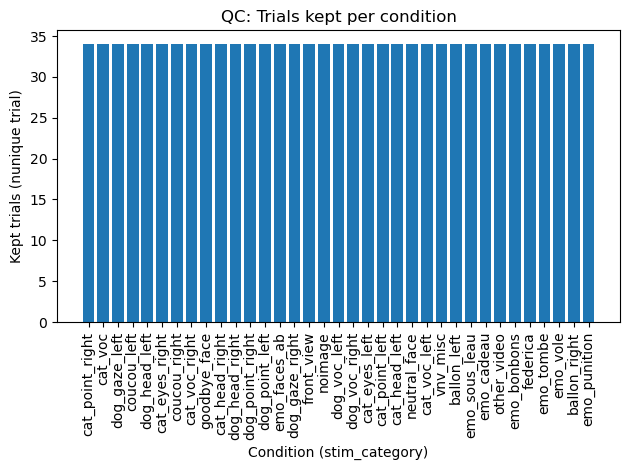

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/1817761046.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_cond, labels=[str(c) for c in cond_order], showfliers=False)


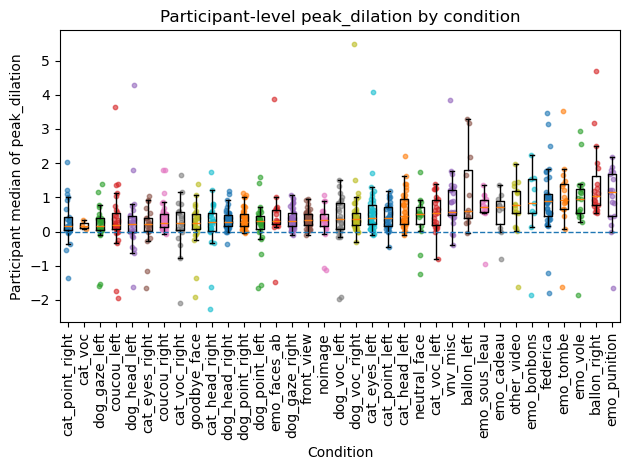

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/1817761046.py:104: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pf_plot.pivot_table(index="participant", columns="stim_category", values="feature_median", aggfunc="first")


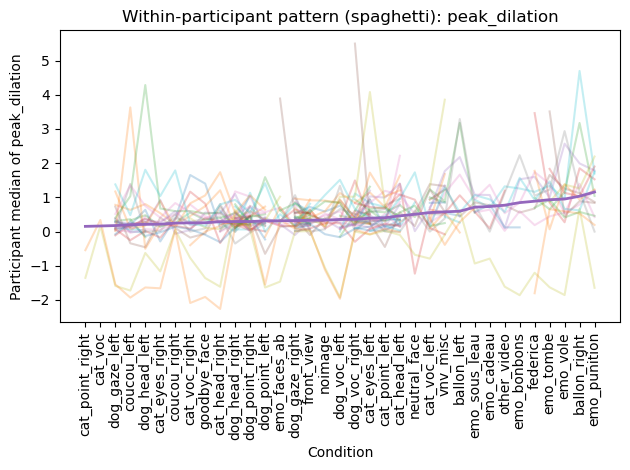

/var/folders/g3/x3j647bn42j_bpmd_9vl047w0000gn/T/ipykernel_98653/1817761046.py:136: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(trial_data_by_cond, labels=[str(c) for c in cond_order], showfliers=False)


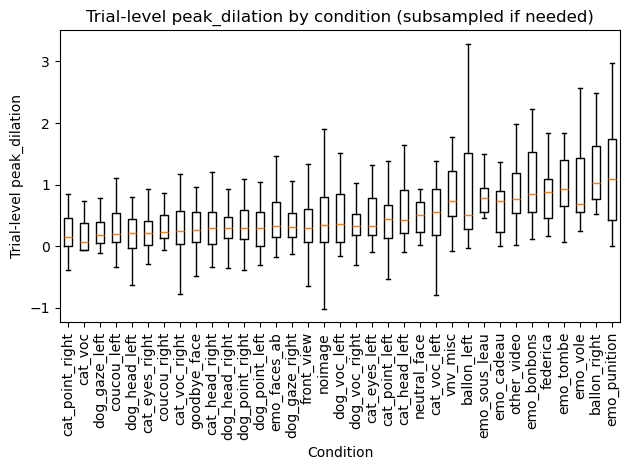

In [16]:
# =========================
# PLOTS: QC + main effects
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Config ----------
PRIMARY_FEATURE = "peak_dilation"   # change to "mean_response" etc if needed
MIN_TRIALS_PER_COND = 5            # for participant-level plots

# trial_features must contain:
# ["participant","trial","stim_category", PRIMARY_FEATURE]
required = {"participant", "trial", "stim_category", PRIMARY_FEATURE}
missing = required - set(trial_features.columns)
if missing:
    raise ValueError(f"trial_features is missing columns: {missing}")

# Ensure sensible dtypes (helps speed + plotting)
tf = trial_features.copy()
tf["participant"] = pd.to_numeric(tf["participant"], errors="coerce").astype("Int64")
tf["stim_category"] = tf["stim_category"].astype("category")
tf[PRIMARY_FEATURE] = pd.to_numeric(tf[PRIMARY_FEATURE], errors="coerce")

# ---------- Participant-level aggregation (robust) ----------
participant_features = (
    tf.groupby(["participant", "stim_category"], observed=True)
      .agg(
          feature_median=(PRIMARY_FEATURE, "median"),
          feature_mean=(PRIMARY_FEATURE, "mean"),
          n_trials=("trial", "nunique")
      )
      .reset_index()
)

# Filter participants who have too few trials per condition (optional but recommended)
pf_plot = participant_features.query("n_trials >= @MIN_TRIALS_PER_COND").copy()

print("Participant-condition rows for plotting:", len(pf_plot))
print("Participants included:", pf_plot["participant"].nunique())

# ---------- Helper: consistent ordering of conditions ----------
# Orders conditions by overall median effect (nice for plots)
cond_order = (
    pf_plot.groupby("stim_category", observed=True)["feature_median"]
           .median()
           .sort_values()
           .index
           .tolist()
)

# ---------- Plot 1: Trials kept per participant (QC bar) ----------
kept_trials_per_participant = (
    tf.groupby("participant")["trial"].nunique().sort_values(ascending=False)
)

plt.figure()
plt.bar(kept_trials_per_participant.index.astype(str), kept_trials_per_participant.values)
plt.xticks(rotation=90)
plt.xlabel("Participant")
plt.ylabel("Kept trials (nunique trial)")
plt.title("QC: Trials kept per participant")
plt.tight_layout()
plt.show()

# ---------- Plot 2: Trials kept per condition (QC bar) ----------
kept_trials_per_condition = (
    tf.groupby("stim_category", observed=True)["trial"].nunique()
      .reindex(cond_order)
)

plt.figure()
plt.bar(kept_trials_per_condition.index.astype(str), kept_trials_per_condition.values)
plt.xticks(rotation=90)
plt.xlabel("Condition (stim_category)")
plt.ylabel("Kept trials (nunique trial)")
plt.title("QC: Trials kept per condition")
plt.tight_layout()
plt.show()

# ---------- Plot 3: Participant-level distribution per condition (box + jitter) ----------
# We'll plot participant medians per condition (each dot = participant)
data_by_cond = [pf_plot.loc[pf_plot["stim_category"] == c, "feature_median"].dropna().to_numpy()
                for c in cond_order]

plt.figure()
plt.boxplot(data_by_cond, labels=[str(c) for c in cond_order], showfliers=False)
# jittered points
for i, c in enumerate(cond_order, start=1):
    y = pf_plot.loc[pf_plot["stim_category"] == c, "feature_median"].dropna().to_numpy()
    x = i + (np.random.rand(len(y)) - 0.5) * 0.25
    plt.scatter(x, y, s=10, alpha=0.6)
plt.xticks(rotation=90)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Condition")
plt.ylabel(f"Participant median of {PRIMARY_FEATURE}")
plt.title(f"Participant-level {PRIMARY_FEATURE} by condition")
plt.tight_layout()
plt.show()

# ---------- Plot 4: Spaghetti plot (within-participant across conditions) ----------
# Each line = participant, y = participant median feature per condition
wide = (
    pf_plot.pivot_table(index="participant", columns="stim_category", values="feature_median", aggfunc="first")
          .reindex(columns=cond_order)
)

plt.figure()
x = np.arange(len(cond_order))
for pid, row in wide.iterrows():
    y = row.to_numpy(dtype=float)
    if np.isfinite(y).sum() < 2:
        continue
    plt.plot(x, y, alpha=0.25)
# overlay grand median line
grand_median = np.nanmedian(wide.to_numpy(dtype=float), axis=0)
plt.plot(x, grand_median, linewidth=2)
plt.xticks(x, [str(c) for c in cond_order], rotation=90)
plt.xlabel("Condition")
plt.ylabel(f"Participant median of {PRIMARY_FEATURE}")
plt.title(f"Within-participant pattern (spaghetti): {PRIMARY_FEATURE}")
plt.tight_layout()
plt.show()

# ---------- Plot 5: Trial-level distribution per condition (optional; can be heavy) ----------
# If you have many trials, you can subsample for speed
MAX_POINTS = 200_000
tf_plot = tf.dropna(subset=[PRIMARY_FEATURE]).copy()
if len(tf_plot) > MAX_POINTS:
    tf_plot = tf_plot.sample(MAX_POINTS, random_state=0)

plt.figure()
# boxplot of trial-level feature
trial_data_by_cond = [tf_plot.loc[tf_plot["stim_category"] == c, PRIMARY_FEATURE].to_numpy()
                      for c in cond_order]
plt.boxplot(trial_data_by_cond, labels=[str(c) for c in cond_order], showfliers=False)
plt.xticks(rotation=90)
plt.xlabel("Condition")
plt.ylabel(f"Trial-level {PRIMARY_FEATURE}")
plt.title(f"Trial-level {PRIMARY_FEATURE} by condition (subsampled if needed)")
plt.tight_layout()
plt.show()